In [1]:
#exploring gut microbiome dataset for patients with and without Autism Spectrum Disorder (ASD) 

In [43]:
#Import libraries for analysis 
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score
from tensorflow.keras.models import Sequential #if tensorflow is not installed, install via kernel with code 'pip install tensorflow'. Please restart environment. 
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping


In [45]:
#import dataset. 
ASD = pd.read_csv('ASDmetaabundance.csv')

#Data is grouped into A (ASD) and B (Control). Therefore grouping of data is required. 
colA = [col for col in ASD.columns if col.startswith("A")]
colB = [col for col in ASD.columns if col.startswith("B")]
datA = ASD[colA]
datB = ASD[colB]

In [47]:
#let's quickly look at the head and foot of the entire dataset. 
#Remove the first hashtag on each line you would like to run. 

ASD.head()
#ASD.tail()           #There are Zero values. We will deal with this later. 

#Let's look at individual groups for fun. 
#datA.head()          #Group A
#datA.tail()

#datB.head()          #Group B
#datB.tail()

,Taxonomy,A3,A5,A6,A9,A31,A51,A52,A53,A54,...,B120,B127,B132,B141,B142,B143,B152,B156,B158,B164
0,g__Faecalibacterium;s__Faecalibacterium prausn...,4988,5060,2905,5745,4822,3889,4646,6337,5064,...,4471,5868,6561,4910,4492,2812,5303,4205,3430,4563
1,g__Hungatella;s__Hungatella hathewayi,5803,5612,4109,1432,2652,4175,3891,894,4903,...,2126,4429,2598,4222,4925,5753,1261,1822,2478,4868
2,g__Clostridium;s__uncultured Clostridium sp.,3793,2795,1355,5558,5383,3505,5541,4429,4121,...,4085,6041,6188,3960,4403,2841,2746,3808,3856,3211
3,g__Butyricimonas;s__Butyricimonas virosa,64,1385,725,1553,40,53,33,175,58,...,2065,21,27,55,35,8,884,13,3,218
4,g__Alistipes;s__Alistipes indistinctus,15,20,723,620,3261,43,83,37,43,...,90,22,30,1027,2641,4,1587,2223,6,1473


In [188]:
#t-test between taxa means for groups
#Define a variance threshold and filter low-variance taxa to lower computational burden. 
variance_threshold = 1e-6  # Adjust this value as needed, this was added due to runtime warning on my computer because of lack of memory. 
datA_filtered = datA.loc[datA.var(axis=1) > variance_threshold]
datB_filtered = datB.loc[datB.var(axis=1) > variance_threshold]

#Making sure the same taxa are displayed for both groups
common_taxa = datA_filtered.index.intersection(datB_filtered.index)
datA_filtered = datA_filtered.loc[common_taxa]
datB_filtered = datB_filtered.loc[common_taxa]

#Perform a t-test for each filtered taxon
p_values = []
taxa_names_filtered = ASD.loc[common_taxa, 'Taxonomy']

for taxon_idx in common_taxa:
    group_A_values = datA_filtered.loc[taxon_idx]
    group_B_values = datB_filtered.loc[taxon_idx]
    
    # Perform a t-test assuming unequal variance (Welch's t-test)
    _, p_val = ttest_ind(group_A_values, group_B_values, equal_var=False, nan_policy='omit')
    p_values.append(p_val)

#Summary DataFrame
stat_results_filtered = pd.DataFrame({
    'Taxonomy': taxa_names_filtered,
    'GroupA_Mean': datA_filtered.mean(axis=1),
    'GroupB_Mean': datB_filtered.mean(axis=1),
    'P-Value': p_values
})

#Column that flags significant taxa (p<0.05)
stat_results_filtered['Significant'] = stat_results_filtered['P-Value'] < 0.05

#Sort by p-value for better visibility of significant taxa
sortedstats = stat_results_filtered.sort_values('P-Value')

#Save the results to a CSV file
sortedstats.to_csv("stat_results.csv", index=False)

#Print the first few rows of the results
print(sortedstats.head())

                                             Taxonomy  GroupA_Mean  \
723         g__Bacteroides;s__Bacteroides sp. CAG:633    11.000000   
746                 g__Prevotella;s__Prevotella amnii     9.833333   
157  g__Parabacteroides;s__Parabacteroides distasonis   344.266667   
853            g__Prevotella;s__Prevotella sp. P5-125     6.666667   
323   g__Bacteroides;s__Bacteroides stercoris CAG:120    71.133333   

     GroupB_Mean       P-Value  Significant  
723     4.200000  1.140371e-08         True  
746     2.600000  1.873520e-08         True  
157   224.466667  5.629838e-08         True  
853     1.966667  7.483983e-08         True  
323    25.400000  9.759996e-08         True  


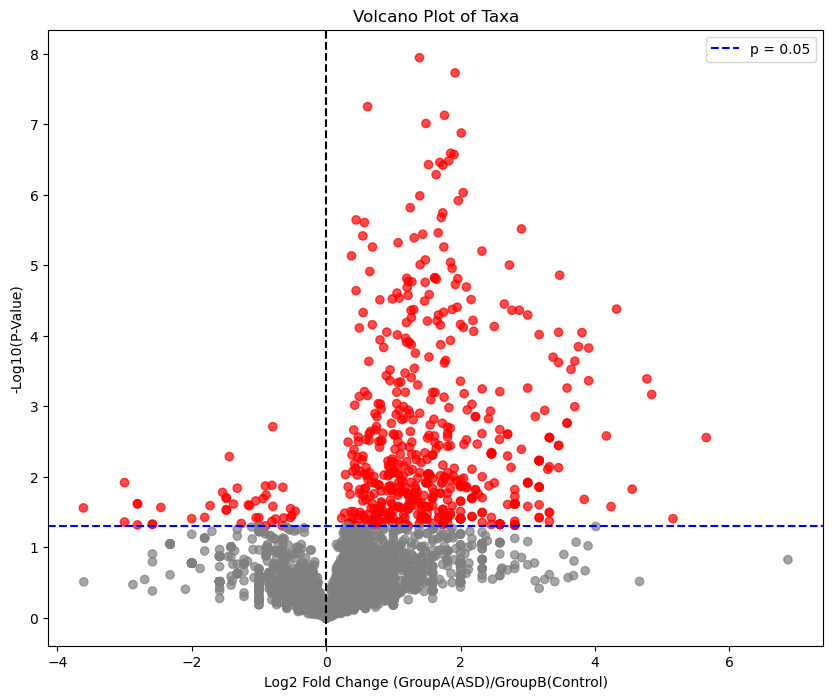

In [50]:
#volcano plot 
#Calculate log2 fold change
sortedstats['Log2FC'] = np.log2(
    sortedstats['GroupA_Mean'] / sortedstats['GroupB_Mean']
)

#Calculate the log of the p-value 
sortedstats['-Log10P'] = -np.log10(sortedstats['P-Value'])

#Plot
plt.figure(figsize=(10, 8))
plt.scatter(sortedstats['Log2FC'], 
            sortedstats['-Log10P'], 
            c=sortedstats['Significant'].map({True: 'red', False: 'gray'}),
            alpha=0.7)

#Thresholds
plt.axhline(-np.log10(0.05), color='blue', linestyle='--', label='p = 0.05')
plt.axvline(0, color='black', linestyle='--')

#labels and legend
plt.xlabel('Log2 Fold Change (GroupA(ASD)/GroupB(Control)')
plt.ylabel('-Log10(P-Value)')
plt.title('Volcano Plot of Taxa')
plt.legend()
plt.show()

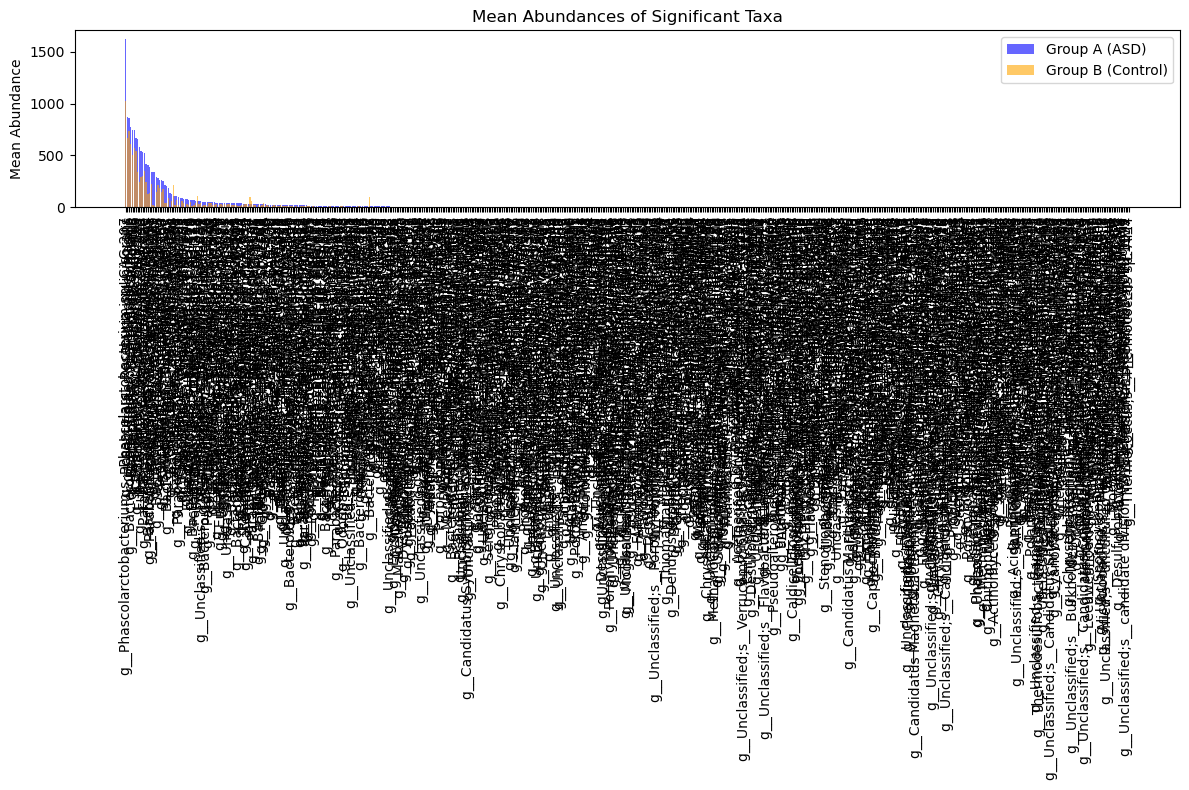

In [53]:
#let's visualise significant taxa using a barplot
#Filter significant taxa
significant_taxa = sortedstats[sortedstats['Significant']]
#they will not be in order, I am reordering so they are descending from mean counts
significant_taxa = significant_taxa.sort_values(by='GroupA_Mean', ascending=False)

#Plot bar chart of mean abundances
plt.figure(figsize=(12, 8))
x = range(len(significant_taxa))
plt.bar(x, significant_taxa['GroupA_Mean'], color='blue', alpha=0.6, label='Group A (ASD)')
plt.bar(x, significant_taxa['GroupB_Mean'], color='orange', alpha=0.6, label='Group B (Control)')
plt.xticks(x, significant_taxa['Taxonomy'], rotation=90)
plt.ylabel('Mean Abundance')
plt.title('Mean Abundances of Significant Taxa')
plt.legend()
plt.tight_layout()
plt.show()

#as you can see it is a mess. let's reduce to top 25 taxa. 

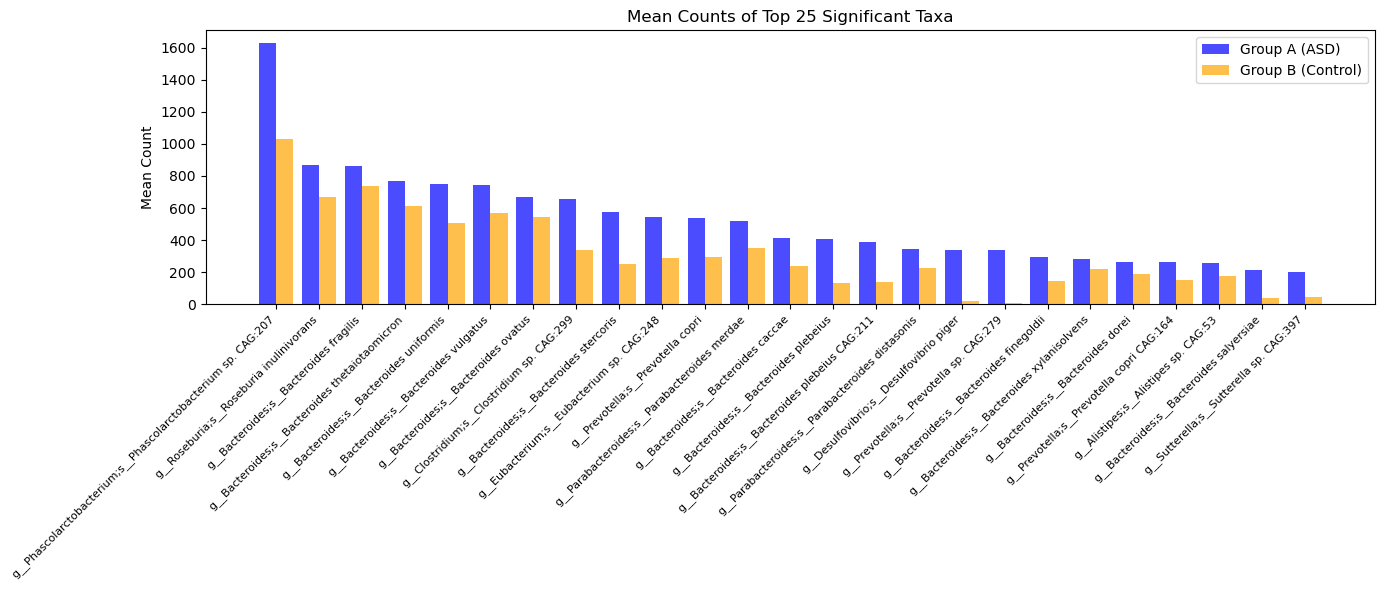

In [55]:
#Use the raw counts (datA and datB) to compute mean counts for the top 25 taxa
top_25_taxa = significant_taxa.head(25)

#Plot side-by-side bar chart for the top 25 taxa based on mean counts (raw data)
plt.figure(figsize=(14, 6))

x = range(len(top_25_taxa))
width = 0.4  # Width of each bar

#Calculate the mean counts for the top 25 taxa in both groups (Group A and Group B)
mean_counts_A = datA.loc[top_25_taxa.index].mean(axis=1)
mean_counts_B = datB.loc[top_25_taxa.index].mean(axis=1)

#Create side-by-side bars for Group A (ASD) and Group B (Control)
plt.bar([pos - width/2 for pos in x], mean_counts_A, width=width, color='blue', alpha=0.7, label='Group A (ASD)')
plt.bar([pos + width/2 for pos in x], mean_counts_B, width=width, color='orange', alpha=0.7, label='Group B (Control)')

#Add labels and legend
plt.xticks(x, top_25_taxa['Taxonomy'], rotation=45, ha='right', fontsize=8)
plt.ylabel('Mean Count')
plt.title('Mean Counts of Top 25 Significant Taxa')
plt.legend()
plt.tight_layout()
plt.show()

#Raw counts can be good to get an idea of sample quality, but fold change between the two can be more intuative. 

In [24]:
#Alternatively, you can investigate the results directly if you want them tabulated
significant_taxa.head(25) #you can adjust the number in the .head(n) function to suit your needs.

,Taxonomy,GroupA_Mean,GroupB_Mean,P-Value,Significant
22,g__Phascolarctobacterium;s__Phascolarctobacter...,1627.100000,1029.900000,2.281748e-03,True
44,g__Roseburia;s__Roseburia inulinivorans,869.733333,667.133333,4.205248e-02,True
61,g__Bacteroides;s__Bacteroides fragilis,863.900000,736.700000,3.865805e-02,True
83,g__Bacteroides;s__Bacteroides thetaiotaomicron,770.133333,614.033333,3.227143e-03,True
80,g__Bacteroides;s__Bacteroides uniformis,749.033333,504.500000,2.480644e-06,True
78,g__Bacteroides;s__Bacteroides vulgatus,743.066667,571.966667,7.370793e-06,True
89,g__Bacteroides;s__Bacteroides ovatus,667.933333,546.766667,9.309998e-03,True
49,g__Clostridium;s__Clostridium sp. CAG:299,654.100000,335.566667,1.526759e-02,True
87,g__Bacteroides;s__Bacteroides stercoris,577.233333,247.800000,2.675860e-05,True
81,g__Eubacterium;s__Eubacterium sp. CAG:248,545.766667,286.700000,1.387453e-02,True


C:\Users\f-hayes\AppData\Local\Temp\ipykernel_24488\2743048149.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_25_taxa['Fold Change'] = top_25_taxa['GroupA_Mean'] / top_25_taxa['GroupB_Mean']


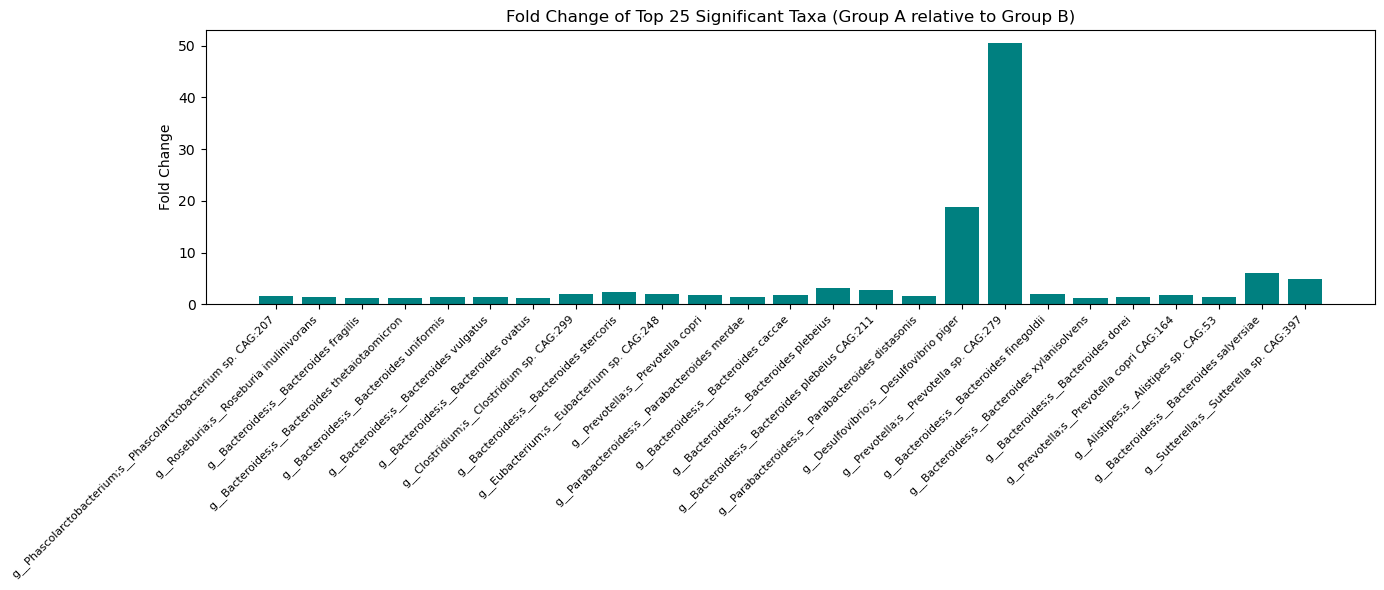

In [57]:
#Visualising taxa differences between groups as fold changes.
top_25_taxa['Fold Change'] = top_25_taxa['GroupA_Mean'] / top_25_taxa['GroupB_Mean']

#plot
plt.figure(figsize=(14, 6))
plt.bar(top_25_taxa['Taxonomy'], top_25_taxa['Fold Change'], color='teal')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.ylabel('Fold Change')
plt.title('Fold Change of Top 25 Significant Taxa (Group A relative to Group B)')
plt.tight_layout()
plt.show()

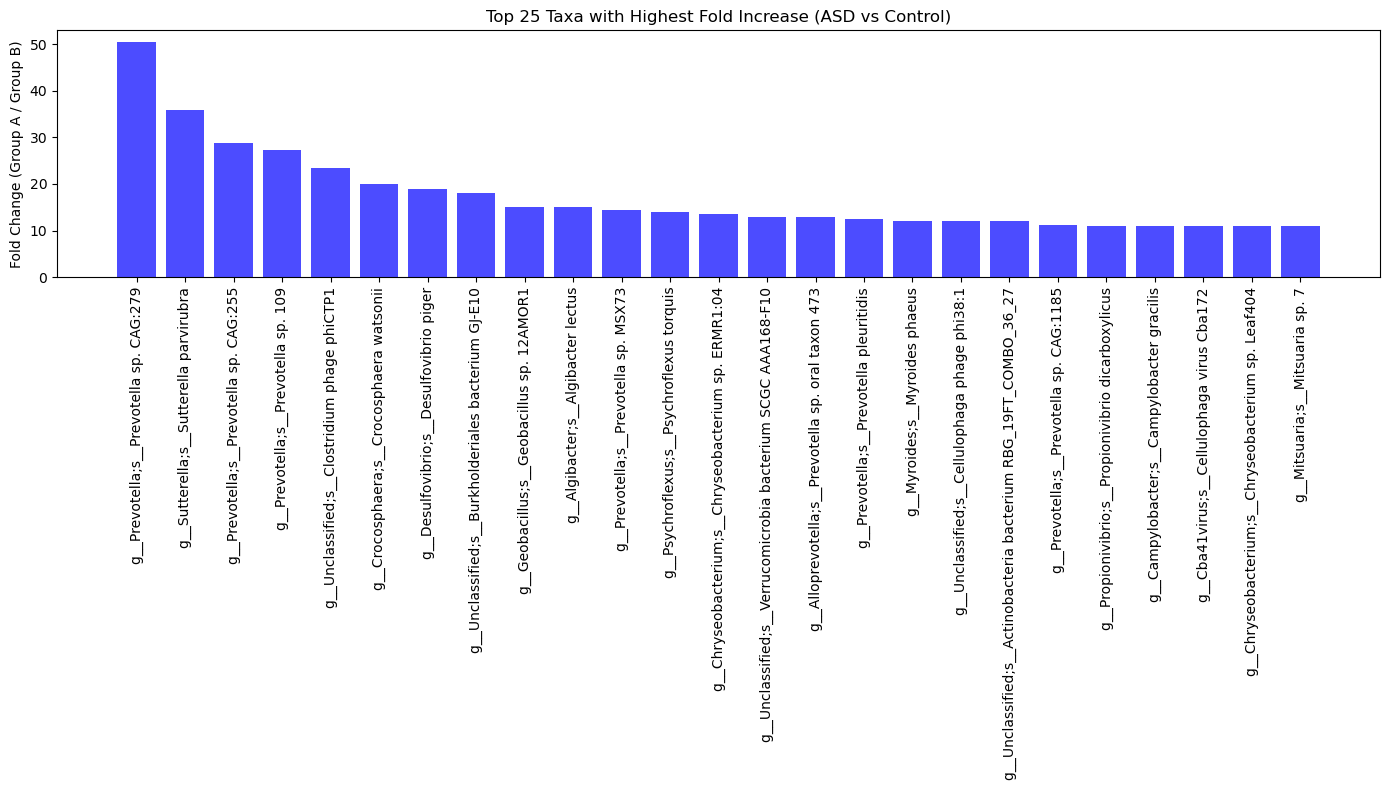

In [59]:
#What about the top 25 in terms of fold-change rather than raw counts?

#Calculate fold change and handle 0
significant_taxa['Fold_Change'] = significant_taxa['.GroupA_Mean'] / significant_taxa['GroupB_Mean']
significant_taxa['Fold_Change'] = significant_taxa['Fold_Change'].replace([np.inf, -np.inf], np.nan).fillna(np.inf)
significant_taxa['Fold_Decrease'] = 1 / significant_taxa['Fold_Change']
significant_taxa['Fold_Decrease'] = significant_taxa['Fold_Decrease'].replace([np.inf, -np.inf], np.nan).fillna(np.inf)

#Add a column to identify whether it's an increase or decrease and export. 
significant_taxa['Change_Type'] = ['Increase' if fc > 1 else 'Decrease' for fc in significant_taxa['Fold_Change']]
output_file = 'fold_changes.csv'
significant_taxa.to_csv(output_file, index=False)

#Select the top 25 taxa with the highest fold change (Group A relative to Group B)
highest_fold_increase = significant_taxa.sort_values(by='Fold_Change', ascending=False).head(25)

#Plot the bar chart
plt.figure(figsize=(14, 8))
x = range(len(highest_fold_increase))
plt.bar(x, highest_fold_increase['Fold_Change'], color='blue', alpha=0.7)
plt.xticks(x, highest_fold_increase['Taxonomy'], rotation=90)
plt.ylabel('Fold Change (Group A / Group B)')
plt.title('Top 25 Taxa with Highest Fold Increase (ASD vs Control)')
plt.tight_layout()
plt.show()

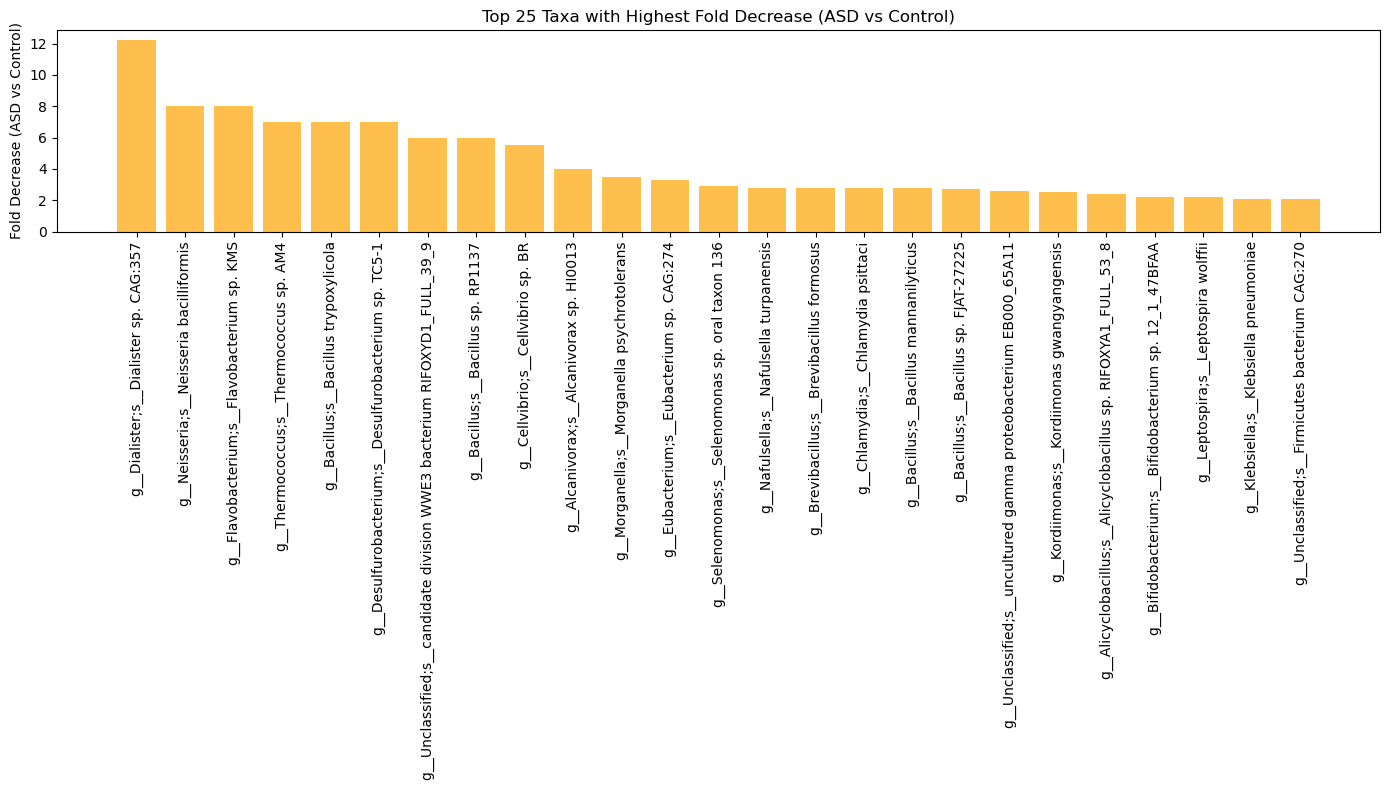

In [61]:
#what about highest-fold decrease in ASD vs control? 

#Calculate the reciprocal for taxa with fold decrease
significant_taxa['Fold_Decrease'] = 1 / significant_taxa['Fold_Change']

#Handle infinite values
significant_taxa['Fold_Decrease'] = significant_taxa['Fold_Decrease'].replace([np.inf, -np.inf], np.nan).fillna(np.inf)

#Select the top 25 taxa with the highest fold decrease (Group A relative to Group B)
highest_fold_decrease = significant_taxa.sort_values(by='Fold_Decrease', ascending=False).head(25)

#Plot the bar chart
plt.figure(figsize=(14, 8))
x = range(len(highest_fold_decrease))
plt.bar(x, highest_fold_decrease['Fold_Decrease'], color='orange', alpha=0.7)
plt.xticks(x, highest_fold_decrease['Taxonomy'], rotation=90)
plt.ylabel('Fold Decrease (ASD vs Control)')
plt.title('Top 25 Taxa with Highest Fold Decrease (ASD vs Control)')
plt.tight_layout()
plt.show()


In [ ]:
### MAKING A PREDICTIVE MODEL ### 
# Can we use a predictive model to identify ASD accurately with only microbiome data?

In [63]:
#A dataset this small will understandably have issues with overfitting. Therefore, I created a second example dataset using the exisiting ASD dataset.
#This new dataset is synthetically balanced with simulated data using SMOTE. 

#Prepare the data
X = pd.concat([datA, datB], axis=1).T  # Features: samples as rows, taxa as columns
y = np.concatenate([np.ones(datA.shape[1]), np.zeros(datB.shape[1])])  # Labels: 1 for ASD, 0 for Control

#Split the data into training and validation sets (80% training, 20% validation)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

#Apply SMOTE to balance the dataset (oversample the minority class)
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

#Convert the resampled data into DataFrame for easier handling
X_train_res_df = pd.DataFrame(X_train_res, columns=X.columns)
y_train_res_df = pd.DataFrame(y_train_res, columns=["Label"])

#Combine the resampled features and labels into a single DataFrame
balanced_data = pd.concat([X_train_res_df, y_train_res_df], axis=1)

#Save the balanced dataset to a new CSV file
balanced_data.to_csv('balanced_dataset.csv', index=False)

#Print the first few rows of the balanced dataset
print(balanced_data.head())



      0     1     2     3    4     5     6     7     8     9  ...  5610  5611  \
0  4397  6238  4624     1    3    41  1850    13  2524  1858  ...     0     0   
1  5745  1432  5558  1553  620  1320  2675    44   107  1726  ...     0     0   
2  6561  2598  6188    27   30   159  2018  1456   389  1868  ...     0     0   
3  5240  2065  3464     7   49    70  1807    15  2534  1231  ...     0     0   
4  5064  4903  4121    58   43    60  1904    17  2034   919  ...     0     0   

   5612  5613  5614  5615  5616  5617  5618  Label  
0     0     0     0     0     0     0     0    0.0  
1     0     0     0     0     0     0     0    1.0  
2     0     0     0     0     0     0     0    0.0  
3     0     0     0     0     0     0     0    1.0  
4     0     0     0     0     0     0     0    1.0  

[5 rows x 5620 columns]


Epoch 1/100


C:\Users\f-hayes\AppData\Local\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.3914 - loss: 58.4983 - val_accuracy: 0.4167 - val_loss: 4.9381
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5360 - loss: 13.9689 - val_accuracy: 0.3333 - val_loss: 4.8252
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6896 - loss: 6.5869 - val_accuracy: 0.3333 - val_loss: 5.1741
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6155 - loss: 7.6528 - val_accuracy: 0.3333 - val_loss: 3.5404
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4318 - loss: 7.6086 - val_accuracy: 0.3333 - val_loss: 2.5841
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4363 - loss: 10.0892 - val_accuracy: 0.4167 - val_loss: 2.0296
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4780 - loss: 18.3658 - val_accuracy: 0.3333 - val_loss: 1.4742
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5991 - loss: 6.2851 - val_accuracy: 0.2500 - val_loss: 1.5232


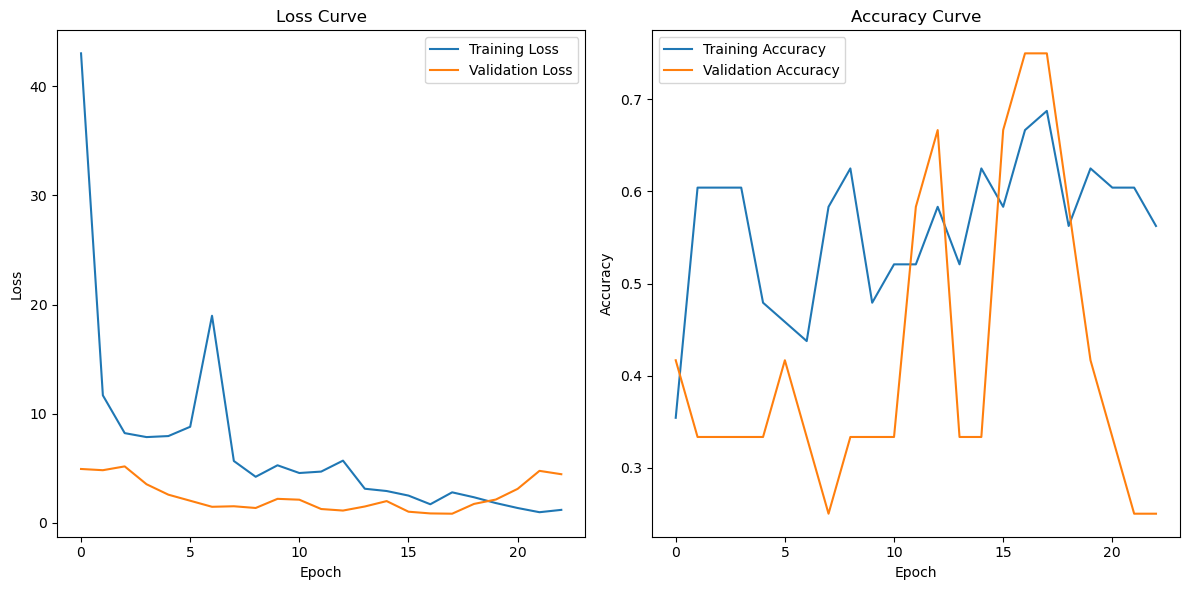

In [186]:

#Simple Neural Network
model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train.shape[1],), kernel_regularizer=regularizers.l2(0.01)),
    Dropout(0.4),  
    Dense(16, activation='relu', kernel_regularizer=regularizers.l2(0.01)), 
    Dropout(0.4),
    Dense(1, activation='sigmoid') 
])

#Compile model
model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])

#Early stopping to stop overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

#Fit the model with early stopping to prevent overfitting
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), 
                    epochs=100, batch_size=8, callbacks=[early_stopping])

#Print final testing accuracy and validation
print(f"Final Training Loss: {history.history['loss'][-1]}")
print(f"Final Validation Loss: {history.history['val_loss'][-1]}")
print(f"Final Training Accuracy: {history.history['accuracy'][-1]}")
print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]}")

#Plot the loss curve
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

#Plot the accuracy curve
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

model.save('ASD_gut_microbiome_model.h5')

In [ ]:
#Even after balancing the dataset, validation accuracy suggests overfitting. 
#model accuracy is moderately high, and so is validation. However, such a high decrease between training vs validation accuracy suggests diffuclty generalising. 
#what about decision tree?


In [200]:
#Random Forest Model
rf_model = RandomForestClassifier(
    n_estimators=100,         
    max_depth=5,              
    class_weight='balanced',  
    random_state=42           
)

#Train the Random Forest Model
rf_model.fit(X_train, y_train)

#Evaluate Random Forest on Training and Validation Sets
y_train_pred_rf = rf_model.predict(X_train)
y_val_pred_rf = rf_model.predict(X_val)
train_accuracy_rf = accuracy_score(y_train, y_train_pred_rf)
val_accuracy_rf = accuracy_score(y_val, y_val_pred_rf)

print(f"Random Forest Training Accuracy: {train_accuracy_rf:.2f}")
print(f"Random Forest Validation Accuracy: {val_accuracy_rf:.2f}")
print("\nRandom Forest Classification Report (Validation Set):")
print(classification_report(y_val, y_val_pred_rf))
print("Random Forest Confusion Matrix (Validation Set):")
print(confusion_matrix(y_val, y_val_pred_rf))

#Cross-Validation to Evaluate Generalization
cv_scores_rf = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='accuracy')
print(f"\nRandom Forest Cross-Validation Accuracy: {cv_scores_rf.mean():.2f} ± {cv_scores_rf.std():.2f}")



Random Forest Training Accuracy: 1.00
Random Forest Validation Accuracy: 0.50

Random Forest Classification Report (Validation Set):
              precision    recall  f1-score   support

         0.0       0.75      0.38      0.50         8
         1.0       0.38      0.75      0.50         4

    accuracy                           0.50        12
   macro avg       0.56      0.56      0.50        12
weighted avg       0.62      0.50      0.50        12

Random Forest Confusion Matrix (Validation Set):
[[3 5]
 [1 3]]

Random Forest Cross-Validation Accuracy: 0.85 ± 0.11
